Cell 1 — Install dependencies


In [1]:
!pip install vaderSentiment transformers torch pandas tqdm


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!{sys.executable} -m pip install torch==2.3.0 torchvision==0.18.0 --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu
     ---------------------------------------- 0.0/161.7 MB ? eta -:--:--
     -- ------------------------------------ 8.9/161.7 MB 46.0 MB/s eta 0:00:04
     ---- --------------------------------- 20.7/161.7 MB 50.4 MB/s eta 0:00:03
     ------- ------------------------------ 31.5/161.7 MB 52.5 MB/s eta 0:00:03
     --------- ---------------------------- 41.7/161.7 MB 50.9 MB/s eta 0:00:03
     ------------ ------------------------- 52.4/161.7 MB 51.3 MB/s eta 0:00:03
     --------------- ---------------------- 65.0/161.7 MB 53.1 MB/s eta 0:00:02
     ----------------- -------------------- 76.3/161.7 MB 52.9 MB/s eta 0:00:02
     -------------------- ----------------- 87.0/161.7 MB 52.4 MB/s eta 0:00:02
     ---------------------- -------------- 100.4/161.7 MB 53.4 MB/s eta 0:00:02
     ------------------------- ----------- 113.2/161.7 MB 54.0 MB/s eta 0:00:01
     ----------------------------- ------- 127.1/161.7 MB 54.9 MB/s et


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



   ------------------------ --------------- 3/5 [torch]
   ------------------------ --------------- 3/5 [torch]
   ------------------------ --------------- 3/5 [torch]
   ------------------------ --------------- 3/5 [torch]
   ------------------------ --------------- 3/5 [torch]
   ------------------------ --------------- 3/5 [torch]
   ------------------------ --------------- 3/5 [torch]
   ------------------------ --------------- 3/5 [torch]
   ------------------------ --------------- 3/5 [torch]
   ------------------------ --------------- 3/5 [torch]
   ------------------------ --------------- 3/5 [torch]
   ------------------------ --------------- 3/5 [torch]
   ------------------------ --------------- 3/5 [torch]
   ------------------------ --------------- 3/5 [torch]
   ------------------------ --------------- 3/5 [torch]
   ------------------------ --------------- 3/5 [torch]
   ------------------------ --------------- 3/5 [torch]
   ------------------------ --------------- 3/5

Cell 2 — Imports


In [2]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import pipeline
from tqdm import tqdm

tqdm.pandas()

Cell 3 — Load your clean data


In [3]:
df = pd.read_csv('friends_clean.csv')
print(df.shape)
df.head(3)

(54008, 11)


,Season,Episode,EpisodeLabel,WrittenBy,Scene,Location,Character,IsMainCharacter,IsChorusLine,Dialogue,WordCount
0,1,1,S01E01,Marta Kauffman & David Crane,"[Scene: Central Perk, Chandler, Joey, Phoebe, ...",Central Perk,monica,True,False,There's nothing to tell! He's just some guy I ...,11
1,1,1,S01E01,Marta Kauffman & David Crane,"[Scene: Central Perk, Chandler, Joey, Phoebe, ...",Central Perk,joey,True,False,"C'mon, you're going out with the guy! There's ...",14
2,1,1,S01E01,Marta Kauffman & David Crane,"[Scene: Central Perk, Chandler, Joey, Phoebe, ...",Central Perk,chandler,True,False,"All right Joey, be nice. So does he have a hu...",16


Cell 4 — VADER sentiment (fast, runs on all 54k rows in ~1 min)


In [4]:
analyzer = SentimentIntensityAnalyzer()

def get_vader_scores(text):
    if pd.isna(text) or text.strip() == '':
        return 0.0, 0.0, 0.0, 0.0
    scores = analyzer.polarity_scores(str(text))
    return scores['pos'], scores['neg'], scores['neu'], scores['compound']

print("Running VADER on all lines...")
df[['vader_pos', 'vader_neg', 'vader_neu', 'vader_compound']] = df['Dialogue'].progress_apply(
    lambda x: pd.Series(get_vader_scores(x))
)

# Sentiment label from compound score
def vader_label(compound):
    if compound >= 0.05:  return 'positive'
    elif compound <= -0.05: return 'negative'
    else: return 'neutral'

df['sentiment'] = df['vader_compound'].apply(vader_label)

print("Done.")
print(df['sentiment'].value_counts())

Running VADER on all lines...


100%|██████████| 54008/54008 [00:11<00:00, 4722.67it/s]


Done.
sentiment
positive    23611
neutral     22160
negative     8237
Name: count, dtype: int64


Cell 5 — Emotion classification (HuggingFace, runs on main cast only ~47k rows, takes 10–20 mins on CPU, ~2 mins on GPU)


In [5]:
# Load the emotion model — downloads ~300MB first time
emotion_classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=1,           # just the top emotion per line
    device=-1          # use CPU; change to 0 for GPU
)

# Run only on main cast to save time — you can remove the filter for all rows
main_mask = df['IsMainCharacter'] == True

# Truncate to 512 chars — model has a token limit
texts = df.loc[main_mask, 'Dialogue'].fillna('').str[:512].tolist()

print(f"Classifying {len(texts):,} lines for emotion...")

# Batch processing — batch_size=32 is safe for CPU
results = []
batch_size = 32
for i in tqdm(range(0, len(texts), batch_size)):
    batch = texts[i:i+batch_size]
    preds = emotion_classifier(batch, truncation=True, max_length=128)
    for pred in preds:
        results.append(pred[0]['label'])

df.loc[main_mask, 'emotion'] = results
df['emotion'] = df['emotion'].fillna('unknown')

print("Done.")
print(df.loc[main_mask, 'emotion'].value_counts())

c:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

c:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\dell\.cache\huggingface\hub\models--j-hartmann--emotion-english-distilroberta-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Classifying 46,963 lines for emotion...


100%|██████████| 1468/1468 [39:21<00:00,  1.61s/it]

Done.
emotion
neutral     14810
surprise    12538
anger        6373
joy          6066
disgust      4106
sadness      1888
fear         1182
Name: count, dtype: int64


Cell 6 — Vocabulary richness (Type-Token Ratio per character)


In [6]:
def ttr(texts):
    """Type-Token Ratio — unique words / total words. Higher = richer vocabulary."""
    all_words = ' '.join(texts.fillna('')).lower().split()
    if len(all_words) == 0:
        return 0
    return round(len(set(all_words)) / len(all_words), 4)

vocab_richness = df[df['IsMainCharacter']].groupby('Character')['Dialogue'].apply(ttr).reset_index()
vocab_richness.columns = ['Character', 'vocab_ttr']
print(vocab_richness.sort_values('vocab_ttr', ascending=False))

  Character  vocab_ttr
3    phoebe     0.1376
0  chandler     0.1352
1      joey     0.1296
2    monica     0.1284
5      ross     0.1280
4    rachel     0.1179


Cell 7 — Character interaction (shared scene co-occurrence)


In [7]:
from itertools import combinations

# Group by Season + Episode + Scene, get all characters per scene
scene_groups = (
    df[df['IsMainCharacter']]
    .groupby(['Season', 'Episode', 'Scene'])['Character']
    .apply(lambda x: list(set(x)))
    .reset_index()
)

# Build edge list
edges = []
for _, row in scene_groups.iterrows():
    chars = row['Character']
    if len(chars) > 1:
        for a, b in combinations(sorted(chars), 2):
            edges.append({'source': a, 'target': b,
                          'season': row['Season']})

edge_df = pd.DataFrame(edges)
interaction_counts = (
    edge_df.groupby(['source', 'target'])
    .size()
    .reset_index(name='shared_scenes')
    .sort_values('shared_scenes', ascending=False)
)
print(interaction_counts.head(15))

      source  target  shared_scenes
1   chandler  monica            862
0   chandler    joey            804
14    rachel    ross            742
9     monica  phoebe            729
10    monica  rachel            700
12    phoebe  rachel            690
5       joey  monica            657
7       joey  rachel            656
4   chandler    ross            653
8       joey    ross            652
6       joey  phoebe            640
2   chandler  phoebe            620
3   chandler  rachel            601
11    monica    ross            591
13    phoebe    ross            587


Cell 8 — Monologue detection


In [8]:
df['is_monologue'] = df['WordCount'] >= 50

monologues = (
    df[df['IsMainCharacter'] & df['is_monologue']]
    .groupby('Character')
    .agg(
        monologue_count=('is_monologue', 'sum'),
        avg_monologue_words=('WordCount', 'mean')
    )
    .round(1)
    .sort_values('monologue_count', ascending=False)
)
print(monologues)

           monologue_count  avg_monologue_words
Character                                      
ross                   153                 79.5
joey                   143                 67.7
rachel                 142                 80.3
phoebe                 125                 70.3
chandler               120                 66.9
monica                  85                 66.6


Cell 9 — Save everything


In [9]:
# Main enriched dataset
df.to_csv('friends_enriched.csv', index=False)

# Aggregated tables ready to load into Power BI as separate tables
# Sentiment by character + season
sent_agg = (
    df[df['IsMainCharacter']]
    .groupby(['Character', 'Season', 'sentiment'])
    .size()
    .reset_index(name='line_count')
)
sent_agg.to_csv('friends_sentiment_agg.csv', index=False)

# Emotion by character + season
emotion_agg = (
    df[df['IsMainCharacter'] & (df['emotion'] != 'unknown')]
    .groupby(['Character', 'Season', 'emotion'])
    .size()
    .reset_index(name='line_count')
)
emotion_agg.to_csv('friends_emotion_agg.csv', index=False)

# Interaction network
interaction_counts.to_csv('friends_interactions.csv', index=False)

# Vocabulary richness
vocab_richness.to_csv('friends_vocab_richness.csv', index=False)

# Monologues
monologues.reset_index().to_csv('friends_monologues.csv', index=False)

print("All files saved.")
print("Load into Power BI:")
print("  friends_enriched.csv      — main fact table")
print("  friends_sentiment_agg.csv — sentiment page")
print("  friends_emotion_agg.csv   — emotion heatmap page")
print("  friends_interactions.csv  — network chart page")
print("  friends_vocab_richness.csv— vocabulary card")
print("  friends_monologues.csv    — monologue stats")

All files saved.
Load into Power BI:
  friends_enriched.csv      — main fact table
  friends_sentiment_agg.csv — sentiment page
  friends_emotion_agg.csv   — emotion heatmap page
  friends_interactions.csv  — network chart page
  friends_vocab_richness.csv— vocabulary card
  friends_monologues.csv    — monologue stats


Check 1 — Sentiment distribution looks reasonable


In [10]:
import pandas as pd

df = pd.read_csv('friends_enriched.csv')

# Overall sentiment split
print(df[df['IsMainCharacter']]['sentiment'].value_counts(normalize=True).round(3))

# Per character — does Phoebe skew positive? Does Ross vary?
print(df[df['IsMainCharacter']].groupby('Character')['sentiment'].value_counts(normalize=True).round(3))

sentiment
positive    0.438
neutral     0.406
negative    0.155
Name: proportion, dtype: float64
Character  sentiment
chandler   positive     0.425
           neutral      0.405
           negative     0.170
joey       positive     0.429
           neutral      0.413
           negative     0.158
monica     neutral      0.436
           positive     0.411
           negative     0.153
phoebe     positive     0.470
           neutral      0.374
           negative     0.156
rachel     positive     0.457
           neutral      0.393
           negative     0.150
ross       positive     0.440
           neutral      0.413
           negative     0.147
Name: proportion, dtype: float64


Check 2 — Emotion distribution looks reasonable


In [11]:
print(df[df['IsMainCharacter']]['emotion'].value_counts())

# Per character emotion profile
print(df[df['IsMainCharacter']].groupby(['Character','emotion']).size().unstack(fill_value=0))

emotion
neutral     14810
surprise    12538
anger        6373
joy          6066
disgust      4106
sadness      1888
fear         1182
Name: count, dtype: int64
emotion    anger  disgust  fear   joy  neutral  sadness  surprise
Character                                                        
chandler    1071      689   228   918     2657      308      1901
joey        1117      712   185  1092     2255      270      1968
monica      1091      645   145   950     2434      308      2192
phoebe       892      681   183   936     2140      276      1758
rachel      1118      700   205  1094     2534      380      2527
ross        1084      679   236  1076     2790      346      2192


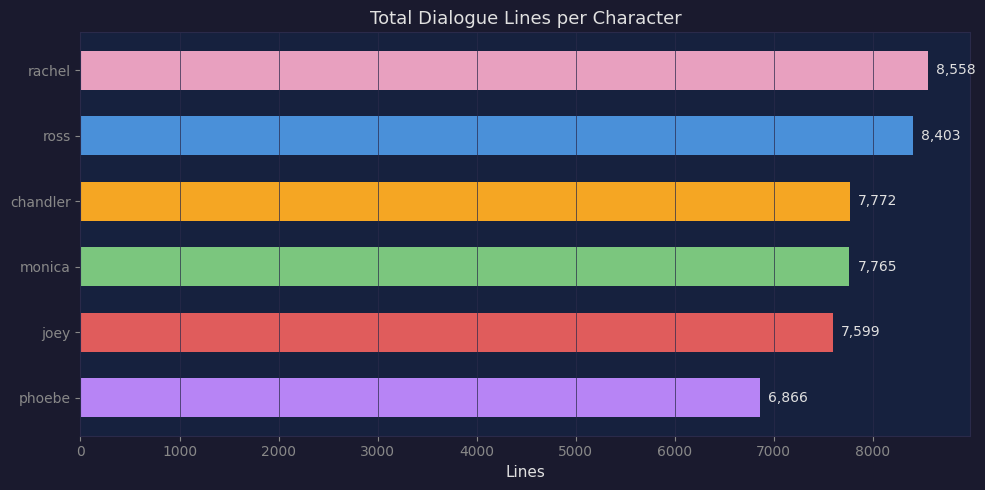

Saved viz_01


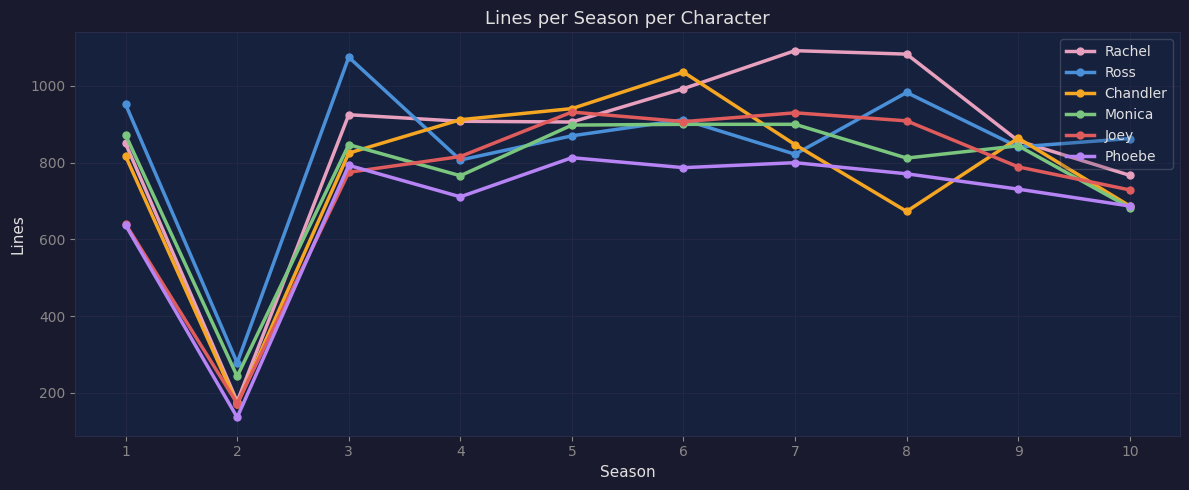

Saved viz_02


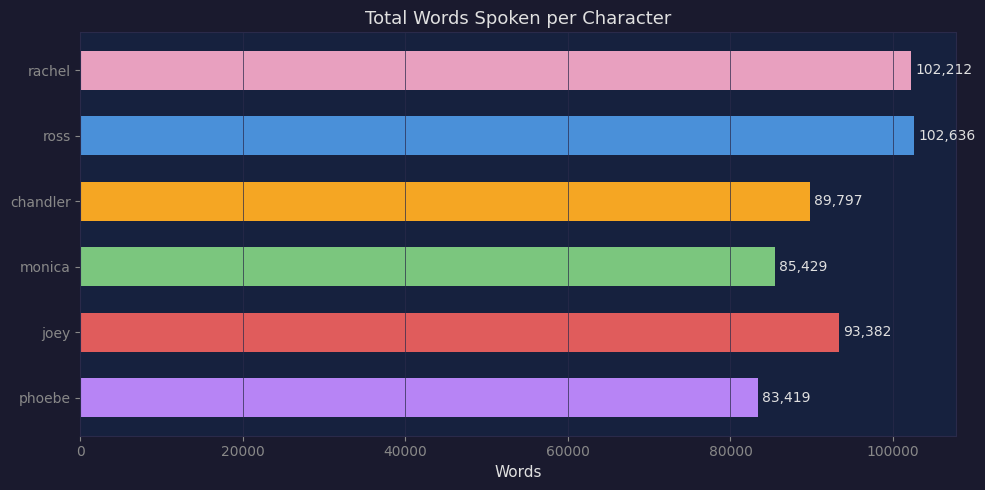

Saved viz_03


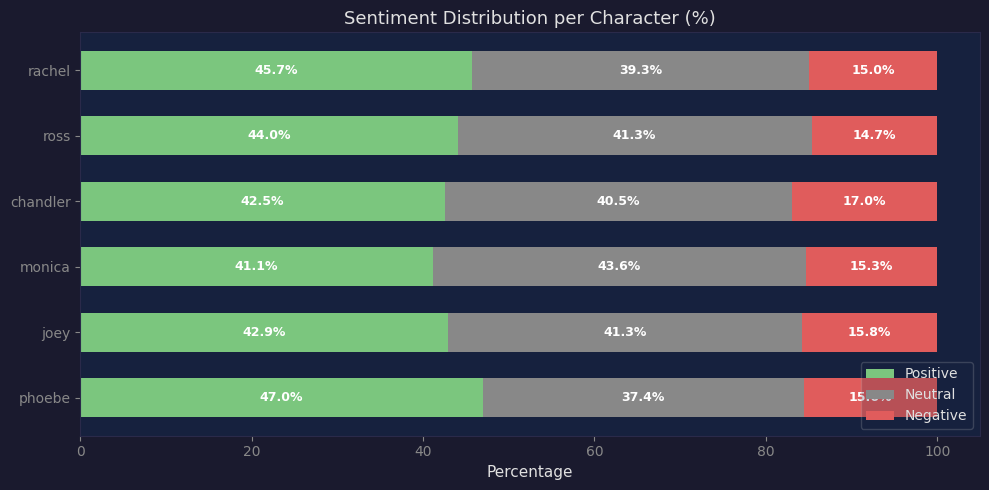

Saved viz_04


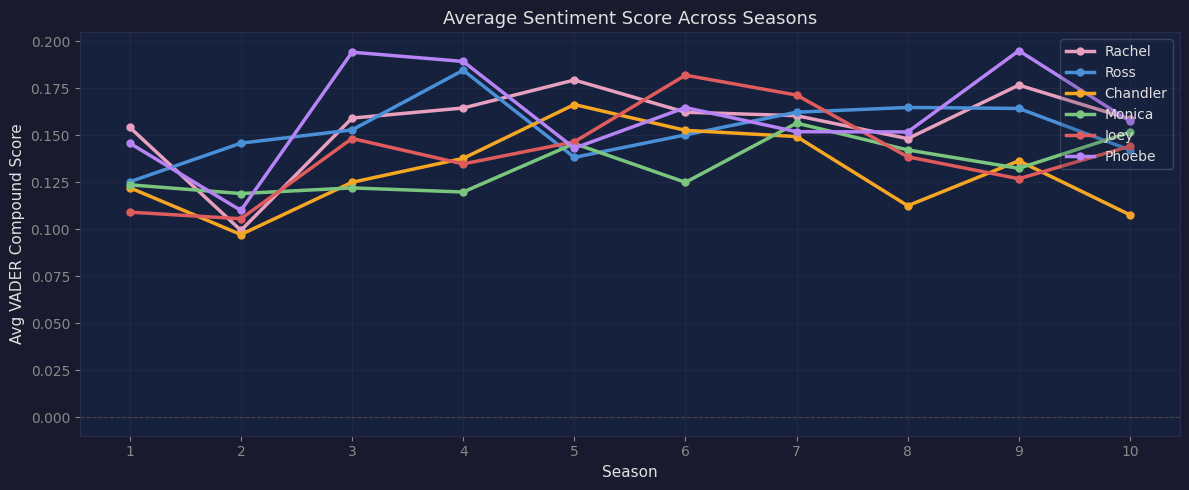

Saved viz_05


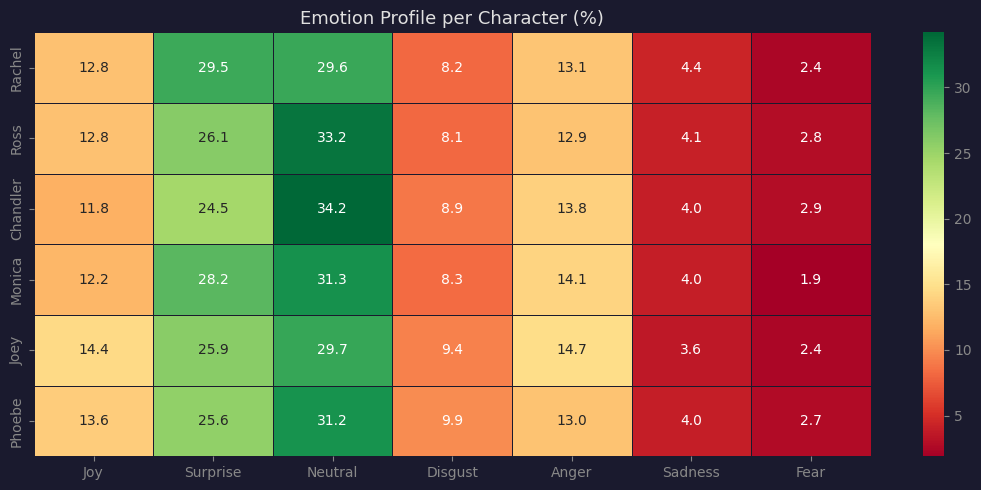

Saved viz_06


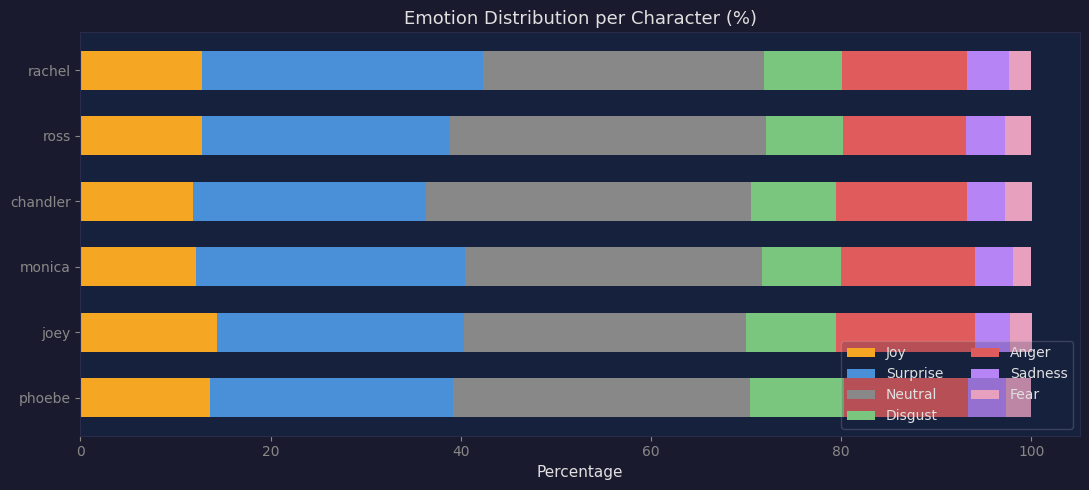

Saved viz_07


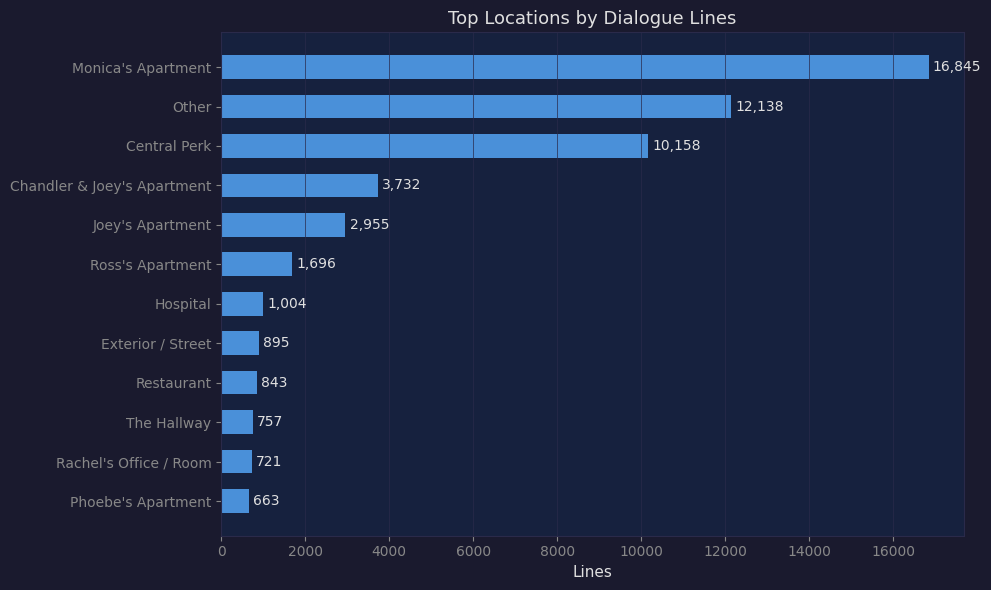

Saved viz_08


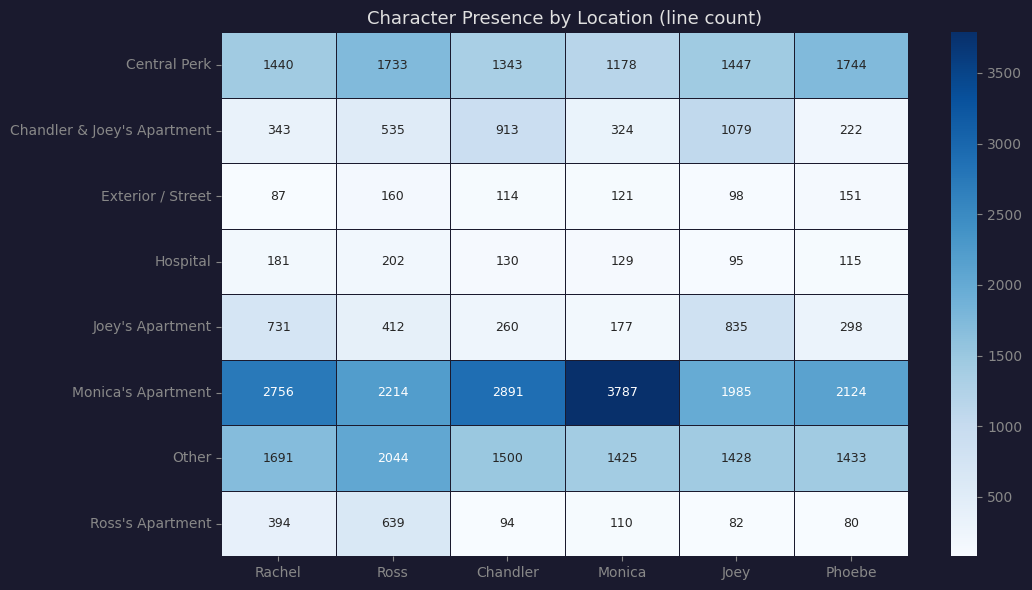

Saved viz_09


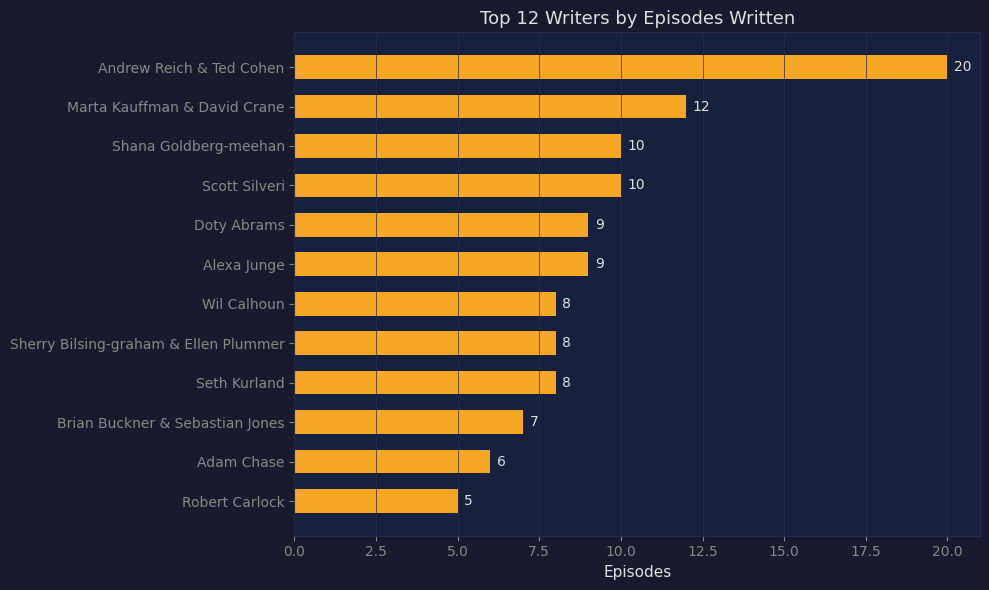

Saved viz_10


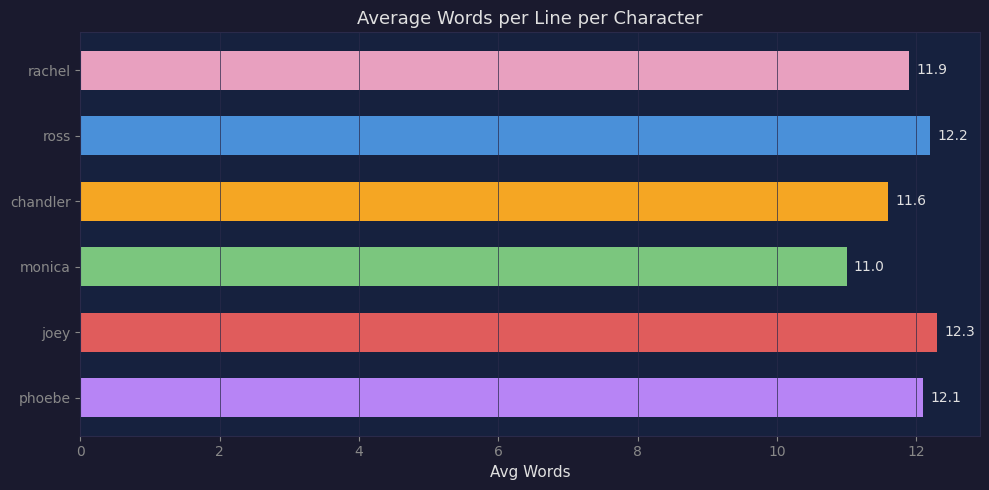

Saved viz_11


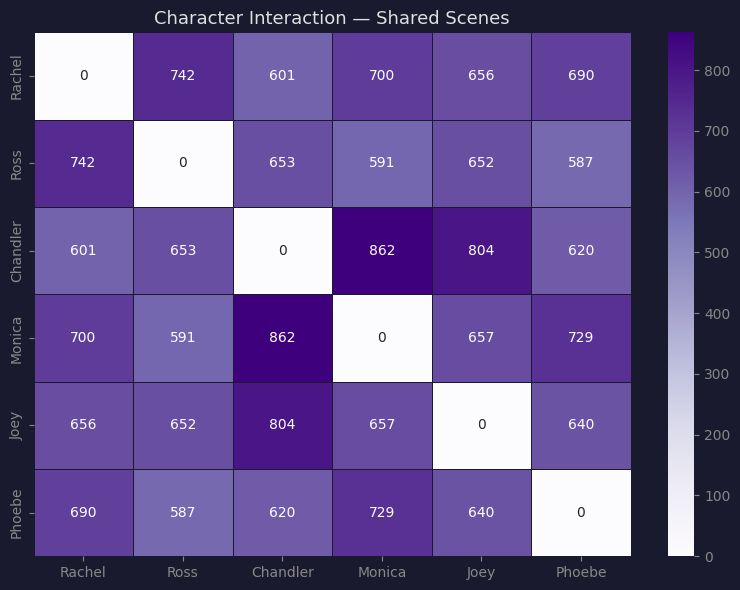

Saved viz_12

All 12 visualisations saved.


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('friends_enriched.csv')

# Character color palette
colors = {
    'ross':     '#4A90D9',
    'rachel':   '#E8A0BF',
    'monica':   '#7BC67E',
    'chandler': '#F5A623',
    'joey':     '#E05C5C',
    'phoebe':   '#B784F5'
}
main = df[df['IsMainCharacter']].copy()
char_order = ['rachel','ross','chandler','monica','joey','phoebe']

# ── Plot style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#1A1A2E',
    'axes.facecolor':    '#16213E',
    'axes.edgecolor':    '#2A2A4A',
    'axes.labelcolor':   '#E0E0E0',
    'xtick.color':       '#888888',
    'ytick.color':       '#888888',
    'text.color':        '#E0E0E0',
    'grid.color':        '#2A2A4A',
    'grid.linewidth':    0.5,
    'font.family':       'sans-serif',
    'axes.titlesize':    13,
    'axes.labelsize':    11,
})

# ═══════════════════════════════════════════════════════════════════════
# 1. TOTAL LINES PER CHARACTER
# ═══════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
counts = main.groupby('Character')['Dialogue'].count().reindex(char_order)
bars = ax.barh(char_order, counts.values,
               color=[colors[c] for c in char_order], height=0.6)
for bar, val in zip(bars, counts.values):
    ax.text(val + 80, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)
ax.set_title('Total Dialogue Lines per Character')
ax.set_xlabel('Lines')
ax.grid(axis='x')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('viz_01_total_lines.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved viz_01")

# ═══════════════════════════════════════════════════════════════════════
# 2. LINES PER SEASON PER CHARACTER
# ═══════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 5))
season_char = main.groupby(['Season','Character'])['Dialogue'].count().unstack()
for char in char_order:
    ax.plot(season_char.index, season_char[char],
            color=colors[char], linewidth=2.5,
            marker='o', markersize=5, label=char.capitalize())
ax.set_title('Lines per Season per Character')
ax.set_xlabel('Season')
ax.set_ylabel('Lines')
ax.set_xticks(range(1,11))
ax.legend(loc='upper right', framealpha=0.2)
ax.grid(True)
plt.tight_layout()
plt.savefig('viz_02_lines_per_season.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved viz_02")

# ═══════════════════════════════════════════════════════════════════════
# 3. TOTAL WORDS PER CHARACTER
# ═══════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
words = main.groupby('Character')['WordCount'].sum().reindex(char_order)
bars = ax.barh(char_order, words.values,
               color=[colors[c] for c in char_order], height=0.6)
for bar, val in zip(bars, words.values):
    ax.text(val + 500, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=10)
ax.set_title('Total Words Spoken per Character')
ax.set_xlabel('Words')
ax.grid(axis='x')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('viz_03_total_words.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved viz_03")

# ═══════════════════════════════════════════════════════════════════════
# 4. SENTIMENT DISTRIBUTION PER CHARACTER
# ═══════════════════════════════════════════════════════════════════════
sent_pct = (
    main.groupby(['Character','sentiment']).size()
    .unstack(fill_value=0)
    .apply(lambda x: x/x.sum()*100, axis=1)
    .reindex(char_order)
)
fig, ax = plt.subplots(figsize=(10, 5))
sent_colors = {'positive':'#7BC67E','neutral':'#888888','negative':'#E05C5C'}
bottom = pd.Series([0.0]*len(char_order), index=char_order)
for sent in ['positive','neutral','negative']:
    vals = sent_pct[sent]
    bars = ax.barh(char_order, vals, left=bottom,
                   color=sent_colors[sent], label=sent.capitalize(), height=0.6)
    for bar, val in zip(bars, vals):
        if val > 8:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}%', ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold')
    bottom += vals
ax.set_title('Sentiment Distribution per Character (%)')
ax.set_xlabel('Percentage')
ax.legend(loc='lower right', framealpha=0.2)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('viz_04_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved viz_04")

# ═══════════════════════════════════════════════════════════════════════
# 5. SENTIMENT ARC ACROSS SEASONS (compound score average)
# ═══════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 5))
sent_arc = main.groupby(['Season','Character'])['vader_compound'].mean().unstack()
for char in char_order:
    ax.plot(sent_arc.index, sent_arc[char],
            color=colors[char], linewidth=2.5,
            marker='o', markersize=5, label=char.capitalize())
ax.axhline(0, color='#444', linewidth=0.8, linestyle='--')
ax.set_title('Average Sentiment Score Across Seasons')
ax.set_xlabel('Season')
ax.set_ylabel('Avg VADER Compound Score')
ax.set_xticks(range(1,11))
ax.legend(loc='upper right', framealpha=0.2)
ax.grid(True)
plt.tight_layout()
plt.savefig('viz_05_sentiment_arc.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved viz_05")

# ═══════════════════════════════════════════════════════════════════════
# 6. EMOTION HEATMAP (% per character)
# ═══════════════════════════════════════════════════════════════════════
emotion_pct = (
    main[main['emotion'] != 'unknown']
    .groupby(['Character','emotion']).size()
    .unstack(fill_value=0)
    .apply(lambda x: x/x.sum()*100, axis=1)
    .reindex(char_order)
    .round(1)
)
emotion_order = ['joy','surprise','neutral','disgust','anger','sadness','fear']
emotion_pct = emotion_pct[emotion_order]

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(emotion_pct, annot=True, fmt='.1f', ax=ax,
            cmap='RdYlGn', linewidths=0.5, linecolor='#1A1A2E',
            annot_kws={'size': 10},
            yticklabels=[c.capitalize() for c in char_order])
ax.set_title('Emotion Profile per Character (%)')
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels([e.capitalize() for e in emotion_order], rotation=0)
plt.tight_layout()
plt.savefig('viz_06_emotion_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved viz_06")

# ═══════════════════════════════════════════════════════════════════════
# 7. EMOTION BREAKDOWN PER CHARACTER (stacked bar)
# ═══════════════════════════════════════════════════════════════════════
emotion_colors = {
    'joy':      '#F5A623',
    'surprise': '#4A90D9',
    'neutral':  '#888888',
    'disgust':  '#7BC67E',
    'anger':    '#E05C5C',
    'sadness':  '#B784F5',
    'fear':     '#E8A0BF'
}
fig, ax = plt.subplots(figsize=(11, 5))
bottom = pd.Series([0.0]*len(char_order), index=char_order)
for emo in emotion_order:
    vals = emotion_pct[emo]
    ax.barh(char_order, vals, left=bottom,
            color=emotion_colors[emo], label=emo.capitalize(), height=0.6)
    bottom += vals
ax.set_title('Emotion Distribution per Character (%)')
ax.set_xlabel('Percentage')
ax.legend(loc='lower right', framealpha=0.2, ncol=2)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('viz_07_emotion_stacked.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved viz_07")

# ═══════════════════════════════════════════════════════════════════════
# 8. TOP LOCATIONS
# ═══════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 6))
loc_counts = df[df['Location'] != 'Unknown']['Location'].value_counts().head(12)
bars = ax.barh(loc_counts.index[::-1], loc_counts.values[::-1],
               color='#4A90D9', height=0.6)
for bar, val in zip(bars, loc_counts.values[::-1]):
    ax.text(val + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)
ax.set_title('Top Locations by Dialogue Lines')
ax.set_xlabel('Lines')
ax.grid(axis='x')
plt.tight_layout()
plt.savefig('viz_08_locations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved viz_08")

# ═══════════════════════════════════════════════════════════════════════
# 9. LOCATION × CHARACTER HEATMAP
# ═══════════════════════════════════════════════════════════════════════
top_locs = df[df['Location'] != 'Unknown']['Location'].value_counts().head(8).index
loc_char = (
    main[main['Location'].isin(top_locs)]
    .groupby(['Location','Character']).size()
    .unstack(fill_value=0)
    .reindex(columns=char_order)
)
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(loc_char, annot=True, fmt='d', ax=ax,
            cmap='Blues', linewidths=0.5, linecolor='#1A1A2E',
            annot_kws={'size': 9},
            xticklabels=[c.capitalize() for c in char_order])
ax.set_title('Character Presence by Location (line count)')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('viz_09_location_character.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved viz_09")

# ═══════════════════════════════════════════════════════════════════════
# 10. WRITERS — TOP 12 BY EPISODES
# ═══════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 6))
writer_eps = (
    df.groupby('WrittenBy')['EpisodeLabel'].nunique()
    .sort_values(ascending=False)
    .head(12)
)
bars = ax.barh(writer_eps.index[::-1], writer_eps.values[::-1],
               color='#F5A623', height=0.6)
for bar, val in zip(bars, writer_eps.values[::-1]):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)
ax.set_title('Top 12 Writers by Episodes Written')
ax.set_xlabel('Episodes')
ax.grid(axis='x')
plt.tight_layout()
plt.savefig('viz_10_writers.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved viz_10")

# ═══════════════════════════════════════════════════════════════════════
# 11. AVG WORDS PER LINE PER CHARACTER
# ═══════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
avg_words = main.groupby('Character')['WordCount'].mean().reindex(char_order).round(1)
bars = ax.barh(char_order, avg_words.values,
               color=[colors[c] for c in char_order], height=0.6)
for bar, val in zip(bars, avg_words.values):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', fontsize=10)
ax.set_title('Average Words per Line per Character')
ax.set_xlabel('Avg Words')
ax.grid(axis='x')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('viz_11_avg_words.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved viz_11")

# ═══════════════════════════════════════════════════════════════════════
# 12. CHARACTER INTERACTION HEATMAP
# ═══════════════════════════════════════════════════════════════════════
interactions = pd.read_csv('friends_interactions.csv')
inter_main = interactions[
    interactions['source'].isin(char_order) &
    interactions['target'].isin(char_order)
]
matrix = pd.DataFrame(0, index=char_order, columns=char_order)
for _, row in inter_main.iterrows():
    matrix.loc[row['source'], row['target']] = row['shared_scenes']
    matrix.loc[row['target'], row['source']] = row['shared_scenes']

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(matrix, annot=True, fmt='d', ax=ax,
            cmap='Purples', linewidths=0.5, linecolor='#1A1A2E',
            annot_kws={'size': 10},
            xticklabels=[c.capitalize() for c in char_order],
            yticklabels=[c.capitalize() for c in char_order])
ax.set_title('Character Interaction — Shared Scenes')
plt.tight_layout()
plt.savefig('viz_12_interactions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved viz_12")

print("\nAll 12 visualisations saved.")